In [1]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from inference import SatelliteImageMatcher

In [2]:
# Initialize the model
matcher = SatelliteImageMatcher(confidence_threshold=0.2)

In [3]:
def draw_matches_inliers_outliers(img1_bgr, img2_bgr, kpts1, kpts2, inliers_mask, max_draw=150):
    """
    Visualizes the correspondences between images:
    - Green lines: Inliers (geometrically confirmed matches)
    - Red lines: Outliers (RANSAC rejected)
    """
    img1 = cv2.cvtColor(img1_bgr, cv2.COLOR_BGR2RGB)
    img2 = cv2.cvtColor(img2_bgr, cv2.COLOR_BGR2RGB)
    
    h1, w1 = img1.shape[:2]
    h2, w2 = img2.shape[:2]
    
    # Create a common canvas (horizontal collage)
    canvas_h = max(h1, h2)
    canvas_w = w1 + w2
    canvas = np.zeros((canvas_h, canvas_w, 3), dtype=np.uint8)
    
    canvas[:h1, :w1] = img1
    canvas[:h2, w1:w1+w2] = img2
    
    # We select a subset of points for the purity of the graph if there are too many
    indices = np.arange(len(kpts1))
    if len(indices) > max_draw:
        np.random.seed(42)
        indices = np.random.choice(indices, size=max_draw, replace=False)
        
    for i in indices:
        pt1 = (int(kpts1[i][0]), int(kpts1[i][1]))
        pt2 = (int(kpts2[i][0] + w1), int(kpts2[i][1]))  
        
        is_inlier = inliers_mask[i]
        
        if is_inlier:
            color = (0, 255, 0)  
            thickness = 1
        else:
            color = (255, 0, 0)  
            thickness = 1
            
        cv2.circle(canvas, pt1, 3, color, -1)
        cv2.circle(canvas, pt2, 3, color, -1)
        cv2.line(canvas, pt1, pt2, color, thickness, cv2.LINE_AA)
        
    inliers_count = int(np.sum(inliers_mask))
    outliers_count = len(inliers_mask) - inliers_count
    
    plt.figure(figsize=(18, 9))
    plt.imshow(canvas)
    plt.title(f"Keypoint Matches: {inliers_count} Inliers (Green), {outliers_count} Outliers (Red)", fontsize=14)
    plt.axis("off")
    plt.tight_layout()
    plt.show()

Testing pair: T36UYA_pair_3_tile_0


c:\Users\Zebra\data_science_projects\Quantum internship test\task2\inference.py:30: DeprecationWarning: Since kornia 0.8.3 the `image_to_tensor` is deprecated in favor of `kornia.image.image_to_tensor`.
  tensor = K.image_to_tensor(img_gray, keepdim=False).float() / 255.0
c:\Users\Zebra\data_science_projects\Quantum internship test\task2\inference.py:30: DeprecationWarning: Since kornia 0.8.3 the `image_to_tensor` is deprecated in favor of `kornia.image.image_to_tensor`.
  tensor = K.image_to_tensor(img_gray, keepdim=False).float() / 255.0


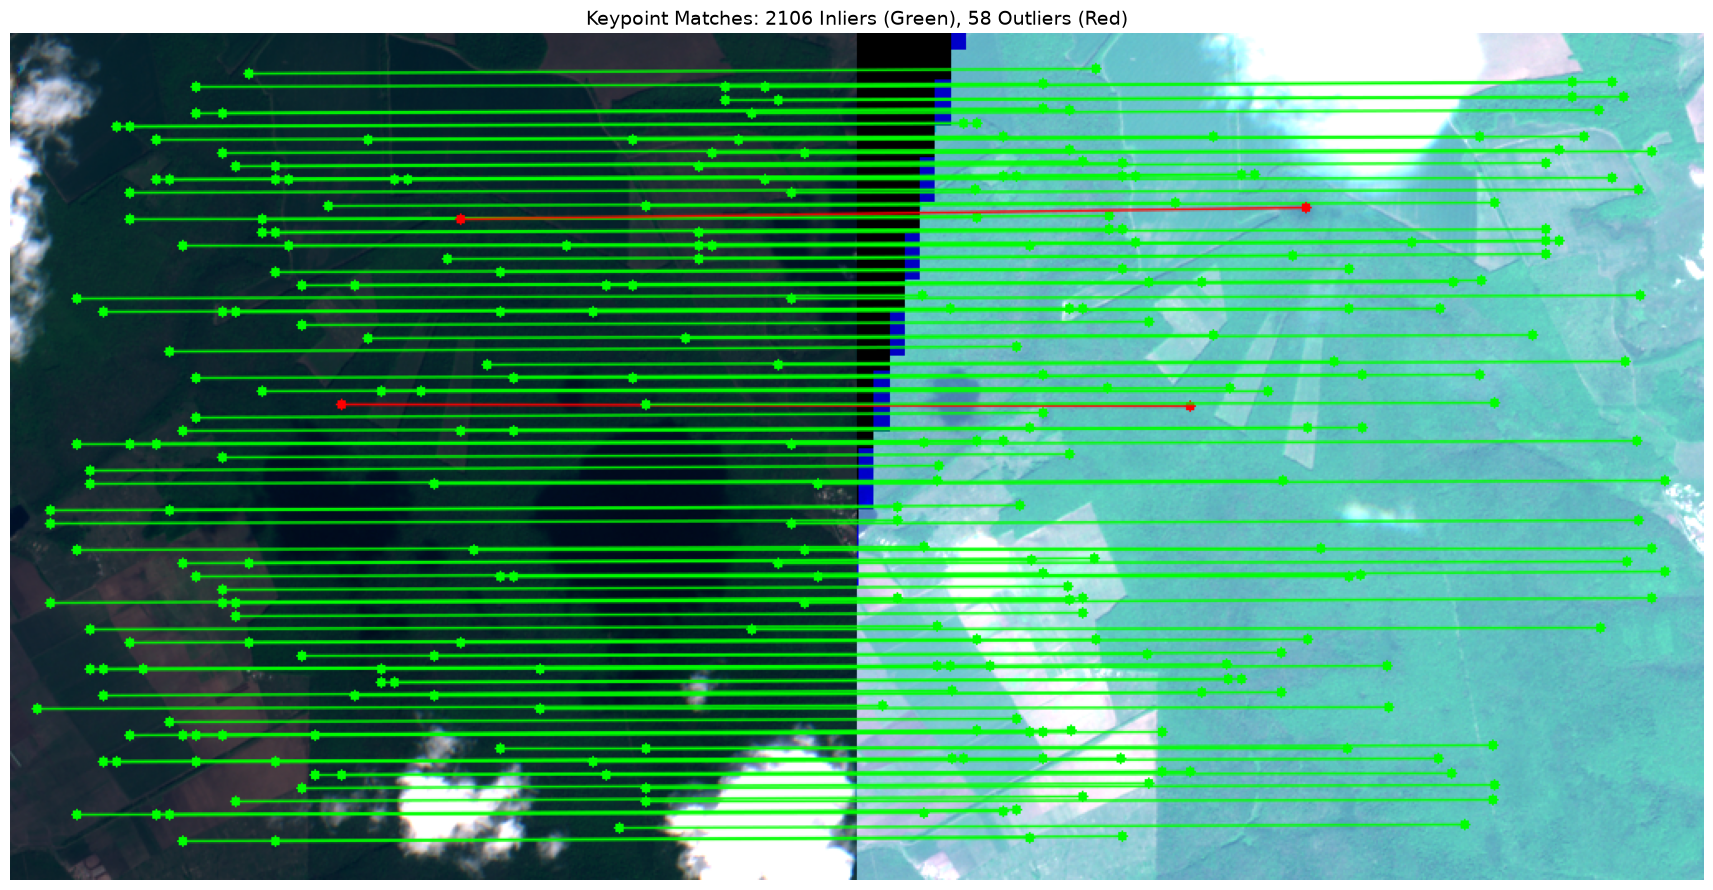

In [4]:
# Loading information about the created pairs
df_pairs = pd.read_csv("data/pairs_metadata.csv")

if len(df_pairs) > 0:
    sample_pair = df_pairs.iloc[0]
    img1_path = sample_pair['tile1_path']
    img2_path = sample_pair['tile2_path']
    
    print(f"Testing pair: {sample_pair['tile_pair_id']}")
    
    # Starting the comparison
    img1, img2, kpts1, kpts2, inliers_mask = matcher.match_pair(img1_path, img2_path)
    
    # Visualization of the result
    draw_matches_inliers_outliers(img1, img2, kpts1, kpts2, inliers_mask)
else:
    print("`pairs_metadata.csv` is empty or not found. Please run `dataset_creation.ipynb` first.")